In [5]:
import sys
#lets you access python's runtime environment
from pathlib import Path
#sys.path is a built in variable in the sys module and contains a list of directories that is seached through when you do an import
#so we are appending the src directory to that
sys.path.append(str(Path().resolve().parent))
import config
from sklearn.model_selection import GridSearchCV, BaseCrossValidator
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
import joblib


panel_data_path = config.PROJECT_ROOT/ "data" /"processed"/ "panel_data_imputed.csv"
panel_data = pd.read_csv(panel_data_path)


features = config.FEATURES

#Year needed for timeaware split
panel = panel_data.loc[:,features + ['Churns']+['Year']]

### Calibration Justification

The model's probabilities are going to be directly used for decision of whether to apply retention intervention. Therefore important these probabilities are calibrated. This has been done on the validation set (2023).

In [2]:
train = panel[panel['Year']<=2022].copy()
#2023 is validation set for calibration
validate = panel[panel['Year']== 2023].copy()
test = panel[panel['Year']==2024].copy()

train_X = train.drop(columns = 'Churns')
train_y = train['Churns']

validate_X = validate.drop(columns = 'Churns')
validate_y = validate['Churns']

test_X = test.drop(columns = 'Churns')
test_y = test['Churns']

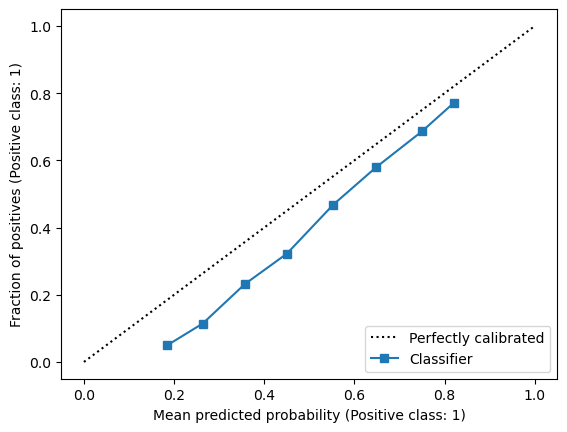

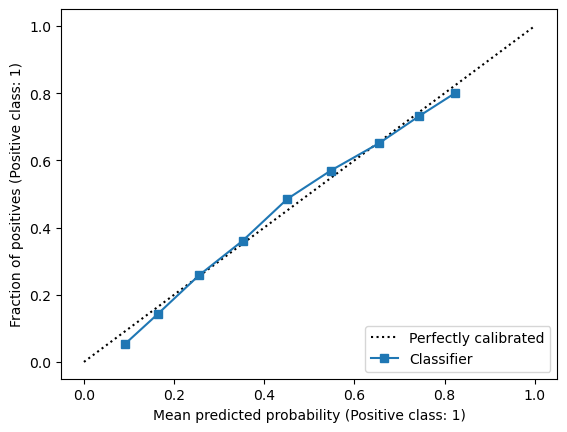

In [3]:
train_X = train_X.drop(columns = 'Year')
validate_X = validate_X.drop(columns = 'Year')
test_X = test_X.drop(columns = 'Year')

clf = HistGradientBoostingClassifier(
    random_state=42,
    learning_rate=config.FINAL_PARAMS['learning_rate'],
    max_depth=config.FINAL_PARAMS['max_depth'],
    max_iter=config.FINAL_PARAMS['max_iter'],
    min_samples_leaf = config.FINAL_PARAMS['min_samples_leaf'],
    l2_regularization=config.FINAL_PARAMS['l2_regularization']
)
clf.fit(train_X, train_y)
probs = clf.predict_proba(test_X)[:, 1]


CalibrationDisplay.from_predictions(test_y, probs, n_bins=10)
plt.show()
calibrated_clf = CalibratedClassifierCV(FrozenEstimator(clf), method='sigmoid')
calibrated_clf.fit(validate_X, validate_y)
probs = calibrated_clf.predict_proba(test_X)[:, 1]



CalibrationDisplay.from_predictions(test_y, probs, n_bins=10)
plt.show()

In [6]:
joblib.dump(calibrated_clf, 'calibrated_model.pkl')

['calibrated_model.pkl']